<a href="https://colab.research.google.com/github/jnardosp/mcmc_random_sampling/blob/main/Tarea_1_Gibbs_Sampler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 Cadenas de Markov
### *Aplicación del muestreo de Gibbs a los modelos Hard-Core y q-coloraciones*

Integrantes del grupo:
- Juan Bernardo Soto Pescador
- Francisco José Gutiérrez Peña
- Tuli Peña Melo

# 1. Muestreo de Gibbs para el Modelo Hard-Core

Here is a implementation of Gibbs sampler algorithm for the hard-core problem.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Create grid for particles

In [ ]:
# Set K value for grid size (kxk) suggested 3<=K<=20
K_list = [3, 5, 10, 15, 20]

def create_k_matrix(K):
    # Create a kxk matrix initialized with no particles (you can actually initialize in whichever way you would like lol)
    initial_grid = np.zeros((K, K), dtype=int)
    initial_grid_2 = np.ones((K, K), dtype=int)

    return initial_grid, initial_grid_2

initial_grid, initial_grid_2 = create_k_matrix(K_list[2])

print(f"Created {K_list[2]}x{K_list[2]} grid:")
print(initial_grid)



Created 10x10 grid:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


### Gibbs random sampler

In [ ]:
def run_gibbs_random(grid, K):
    """Move from X_{n} state to X_{n+1} using Gibbs random sampler."""
    # First we select a random vertex on our grid
    i = random.randint(0, K-1)
    j = random.randint(0, K-1)

    # Sample another value for vertex given the other vertex
    # Check if neighbor vertex are 0 (for possible particle in factible grid)
    # Boundary cases
    neighbors_empty = True  # Start assuming neighbors are empty

    # Check top neighbor (only if not at top boundary)
    if i > 0 and grid[i-1, j] == 1:
        neighbors_empty = False

    # Check bottom neighbor (only if not at bottom boundary)
    if i < K-1 and grid[i+1, j] == 1:
        neighbors_empty = False

    # Check left neighbor (only if not at left boundary)
    if j > 0 and grid[i, j-1] == 1:
        neighbors_empty = False

    # Check right neighbor (only if not at right boundary)
    if j < K-1 and grid[i, j+1] == 1:
        neighbors_empty = False

    if neighbors_empty:
        coin_flipped = random.randint(0,1) # One for heads, zero for tails
        if coin_flipped == 1:
            grid[i, j] = 1 # Put particle
        else:
            grid[i,j] = 0 # Remove particle
    else:
        grid[i,j] = 0 # If neighbors have particles force no particle in vertex

    return grid


### Gibbs sampler w order

In [ ]:
def run_gibbs_order(grid, K, i, j):
    """Move from X_{n} state to X{n+1} using Gibbs sampler with order (for faster convergence)."""
    # Check if neighbor vertex are 0 (for possible particle in factible grid)
    # Boundary cases
    neighbors_empty = True  # Start assuming neighbors are empty

    # Check top neighbor (only if not at top boundary)
    if i > 0 and grid[i-1, j] == 1:
        neighbors_empty = False

    # Check bottom neighbor (only if not at bottom boundary)
    if i < K-1 and grid[i+1, j] == 1:
        neighbors_empty = False

    # Check left neighbor (only if not at left boundary)
    if j > 0 and grid[i, j-1] == 1:
        neighbors_empty = False

    # Check right neighbor (only if not at right boundary)
    if j < K-1 and grid[i, j+1] == 1:
        neighbors_empty = False

    if neighbors_empty:
        coin_flipped = random.randint(0,1) # One for heads, zero for tails
        if coin_flipped == 1:
            grid[i, j] = 1 # Put particle
        else:
            grid[i,j] = 0 # Remove particle
    else:
        grid[i,j] = 0 # If neighbors have particles force no particle in vertex
    # We pass every vertex of grid in order
    if i == K-1:
        if j == K-1:
            # If we changed last column, last row, start in the beginning of the grid
            i = 0
            j = 0
        else:
            j += 1
    else:
        if j == K-1:
            # If we changed last column, i row, change row and j = 0
            i += 1
            j = 0
        else:
            j += 1

    return grid, i, j


### Run Gibbs sampler

In [ ]:
final_time = 100001
chain_times = [500, 5000, 10000, 10001, 10002, 100000]

# Run Gibbs random sampler
def get_gibbs_samples_random(chain_times):
    final_grids = []
    for k in K_list:
        print(f"For K={k} we have:")
        updated_grid, updated_grid_2 = create_k_matrix(k)
        for t in range(final_time):
            updated_grid = run_gibbs_random(updated_grid, k)
            if t in chain_times:
                final_grids.append(updated_grid)
                print(f"X_{t} grid:\n{updated_grid}")

    return final_grids

x = get_gibbs_samples_random(chain_times)


For K=3 we have:
X_500 grid:
[[1 0 1]
 [0 0 0]
 [0 0 1]]
X_5000 grid:
[[0 0 1]
 [1 0 0]
 [0 0 0]]
X_10000 grid:
[[0 1 0]
 [0 0 0]
 [0 0 0]]
X_10001 grid:
[[0 1 0]
 [0 0 0]
 [0 0 0]]
X_10002 grid:
[[0 1 0]
 [0 0 0]
 [0 1 0]]
X_100000 grid:
[[0 1 0]
 [1 0 1]
 [0 1 0]]
For K=5 we have:
X_500 grid:
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 1 0 1 0]
 [0 0 0 0 1]]
X_5000 grid:
[[0 1 0 0 0]
 [1 0 1 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 1 0 0 0]]
X_10000 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_10001 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_10002 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_100000 grid:
[[1 0 0 0 0]
 [0 0 1 0 1]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 1 0 0 0]]
For K=10 we have:
X_500 grid:
[[0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 1 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 1 0 0 0]
 [1 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1]
 

In [ ]:
# Run gibbs w order sampler
chain_times = [500, 5000, 10000, 10001, 10002, 100000]
i = 0
j = 0
def get_gibbs_samples_order(chain_times, i, j):
    final_grids = []
    for k in K_list:
        print(f"For K={k} we have:")
        updated_grid, updated_grid_2 = create_k_matrix(k)
        for t in range(final_time):
            updated_grid, i, j = run_gibbs_order(updated_grid, k, i, j)
            if t in chain_times:
                final_grids.append(updated_grid)
                print(f"X_{t} grid:\n{updated_grid}")

    return final_grids

x = get_gibbs_samples_order(chain_times, i, j)


For K=3 we have:
X_500 grid:
[[0 0 0]
 [0 0 1]
 [0 0 0]]
X_5000 grid:
[[0 1 0]
 [1 0 0]
 [0 0 0]]
X_10000 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_10001 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_10002 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_100000 grid:
[[0 0 0]
 [0 0 0]
 [0 0 1]]
For K=5 we have:
X_500 grid:
[[0 0 1 0 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 1]
 [0 0 0 1 0]]
X_5000 grid:
[[0 0 0 0 0]
 [1 0 0 0 1]
 [0 0 0 1 0]
 [0 1 0 0 0]
 [1 0 0 1 0]]
X_10000 grid:
[[1 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_10001 grid:
[[1 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_10002 grid:
[[1 0 1 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_100000 grid:
[[1 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]
 [1 0 1 0 1]
 [0 0 0 0 0]]
For K=10 we have:
X_500 grid:
[[0 1 0 1 0 0 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 1 0]
 [1 0 1 0 0 1 0 0 0 1]
 [0 0 0 0 1 0 0 0 0 0]
 [1 0 0 1 0 0 1 0 0 0]
 

## Hard-core particle estimation

Using the samples made in the past code we will make a histogram of number of particles for different chain times.

In [ ]:
def count_particles(grid) -> int:
    """Return the number of particles (cells equal to 1) in the grid."""
    arr = np.asarray(grid)
    return int(np.count_nonzero(arr == 1))

In [ ]:
def compute_mean_particles_ordered(runs: int, K_list, chain_times, final_time: int):
    """Return {K: {t: mean_num_particles}} across `runs` for ordered Gibbs."""
    means_by_k = {}
    for K in K_list:
        # accumulator: t -> list of counts
        counts_per_t = {t: [] for t in chain_times}
        for _ in range(runs):
            grid, _grid_ones = create_k_matrix(K)
            i, j = 0, 0
            for step in range(final_time):
                grid, i, j = run_gibbs_order(grid, K, i, j)
                if step in counts_per_t:
                    counts_per_t[step].append(count_particles(grid))
        # convert to means
        means_by_k[K] = {t: float(np.mean(counts)) if counts else 0.0
                         for t, counts in counts_per_t.items()}
    return means_by_k


def plot_mean_particles_hist(means_by_k):
    """Plot bar charts of mean particles at each chain time for every K."""
    # Determine chain_times order from the first K entry
    sample_K = next(iter(means_by_k))
    chain_times_sorted = sorted(means_by_k[sample_K].keys())

    num_K = len(means_by_k)
    cols = 2
    rows = (num_K + cols - 1) // cols
    plt.figure(figsize=(6 * cols, 3.5 * rows))

    for idx, (K, means_dict) in enumerate(sorted(means_by_k.items())):
        plt.subplot(rows, cols, idx + 1)
        values = [means_dict[t] for t in chain_times_sorted]
        plt.bar([str(t) for t in chain_times_sorted], values, color="#4C78A8")
        plt.title(f"K={K} mean particles by chain time")
        plt.xlabel("chain time")
        plt.ylabel("mean # particles")
        plt.tight_layout()

    plt.show()


Mean #particles by K and chain time:
K=3: {10: 2.9, 50: 2.1, 100: 2.1, 500: 2.6, 1000: 2.4, 5000: 2.9, 10000: 2.2, 50000: 2.6, 100000: 1.8}
K=5: {10: 3.8, 50: 6.4, 100: 7.1, 500: 6.0, 1000: 6.1, 5000: 5.7, 10000: 6.4, 50000: 6.6, 100000: 6.0}
K=10: {10: 3.4, 50: 15.1, 100: 29.4, 500: 24.3, 1000: 24.7, 5000: 23.8, 10000: 22.7, 50000: 22.5, 100000: 24.3}
K=15: {10: 4.0, 50: 15.9, 100: 29.3, 500: 50.0, 1000: 54.3, 5000: 52.3, 10000: 55.4, 50000: 51.9, 100000: 51.9}
K=20: {10: 3.9, 50: 15.5, 100: 29.2, 500: 105.8, 1000: 91.5, 5000: 91.1, 10000: 94.5, 50000: 91.5, 100000: 93.0}


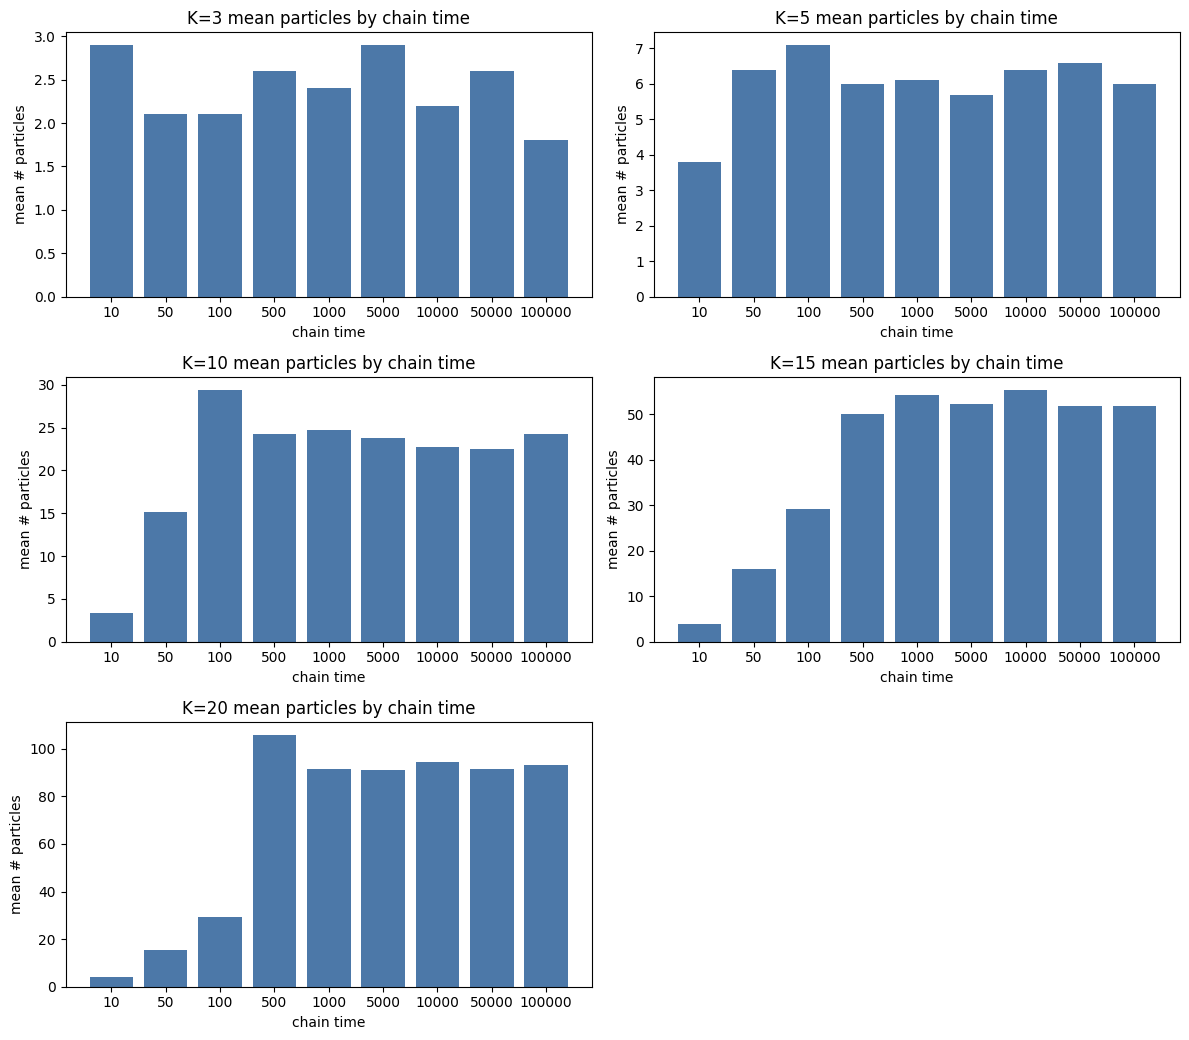

In [ ]:
# Configure parameters and run aggregation
runs = 10  # number of independent runs
chain_times = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
final_time = 100001

means_by_k = compute_mean_particles_ordered(runs, K_list, chain_times, final_time)
print("Mean #particles by K and chain time:")
for K in sorted(means_by_k):
    print(f"K={K}:", {t: round(means_by_k[K][t], 2) for t in sorted(means_by_k[K])})

plot_mean_particles_hist(means_by_k)


### Notes for particle estimation:

For every grid we have that the maximum number of particles with hard-core constraint is $\frac{kxk}{2}$ (chess board), my hypothesis is that because we have a $\frac{1}{2}$ chance of having or not a particle we tend to $\frac{kxk}{4}$ number of particles in the stationary distribution.

## 2. Generalización a q-Coloraciones

Implementación del algoritmo Gibbs sampler para generar muestras de la distribución uniforme sobre las q-coloraciones propias de una rejilla.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter

### Implementación del Gibbs Sampler para q-coloraciones

In [ ]:
def create_grid(K, q):
    """
    Crea una rejilla KxK con una coloración inicial válida.
    Usa un patrón de tablero de ajedrez con dos colores para garantizar una coloración propia inicial.
    """
    grid = np.zeros((K, K), dtype=int)
    for i in range(K):
        for j in range(K):
            # Patrón de tablero de ajedrez usando los primeros dos colores
            grid[i, j] = (i + j) % min(2, q)
    return grid

def get_neighbors(i, j, K):
    """
    Obtiene los vecinos válidos de una posición (i, j) en la rejilla.
    """
    neighbors = []
    # Arriba
    if i > 0:
        neighbors.append((i-1, j))
    # Abajo
    if i < K-1:
        neighbors.append((i+1, j))
    # Izquierda
    if j > 0:
        neighbors.append((i, j-1))
    # Derecha
    if j < K-1:
        neighbors.append((i, j+1))
    return neighbors

def get_valid_colors(grid, i, j, q):
    """
    Obtiene los colores válidos para una posición (i, j) dada la configuración actual.
    Un color es válido si no está presente en ningún vecino.
    """
    K = len(grid)
    neighbors = get_neighbors(i, j, K)

    # Colores usados por los vecinos
    used_colors = set()
    for ni, nj in neighbors:
        used_colors.add(grid[ni, nj])

    # Colores disponibles
    valid_colors = [c for c in range(q) if c not in used_colors]
    return valid_colors

def gibbs_step_q_coloration(grid, q):
    """
    Realiza un paso del Gibbs sampler para q-coloraciones.
    """
    K = len(grid)
    # Seleccionar una posición aleatoria
    i = random.randint(0, K-1)
    j = random.randint(0, K-1)

    # Obtener colores válidos para esa posición
    valid_colors = get_valid_colors(grid, i, j, q)

    if valid_colors:
        # Elegir un color válido uniformemente al azar
        new_color = random.choice(valid_colors)
        grid[i, j] = new_color
    # Si no hay colores válidos (no debería pasar con q >= 3), mantener el color actual

    return grid

def gibbs_sampler_q_coloration(K, q, num_steps, save_steps=None):
    """
    Ejecuta el Gibbs sampler para q-coloraciones.

    Args:
        K: Tamaño de la rejilla (K x K)
        q: Número de colores
        num_steps: Número de pasos de la cadena
        save_steps: Lista de pasos en los que guardar el estado

    Returns:
        grid: Estado final de la rejilla
        saved_states: Estados guardados en los pasos especificados
    """
    grid = create_grid(K, q)
    saved_states = {}

    if save_steps is None:
        save_steps = []

    for step in range(num_steps):
        grid = gibbs_step_q_coloration(grid.copy(), q)

        if step in save_steps:
            saved_states[step] = grid.copy()

    return grid, saved_states

In [ ]:
# Test básico
K = 5
q = 3
grid = create_grid(K, q)
print(f"Rejilla inicial {K}x{K} con {q} colores:")
print(grid)

Rejilla inicial 5x5 con 3 colores:
[[0 1 0 1 0]
 [1 0 1 0 1]
 [0 1 0 1 0]
 [1 0 1 0 1]
 [0 1 0 1 0]]


### Visualización de las q-coloraciones

In [ ]:
def plot_q_coloration(grid, q, title="q-coloración"):
    """
    Visualiza una q-coloración de la rejilla.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Crear un mapa de colores personalizado
    if q <= 10:
        colors = ['white', 'red', 'blue', 'green', 'yellow', 'purple',
                 'orange', 'pink', 'brown', 'gray']
        cmap = mcolors.ListedColormap(colors[:q])
    else:
        cmap = plt.cm.get_cmap('tab20', q)

    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=q-1)

    # Agregar líneas de rejilla
    for i in range(len(grid) + 1):
        ax.axhline(i - 0.5, color='black', linewidth=1)
        ax.axvline(i - 0.5, color='black', linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    # Agregar barra de colores
    cbar = plt.colorbar(im, ax=ax, ticks=range(q))
    cbar.set_label('Color', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

def plot_trajectory_q_coloration(K, q, num_steps, steps_to_show):
    """
    Visualiza la trayectoria del Gibbs sampler mostrando estados en diferentes pasos.
    """
    grid, saved_states = gibbs_sampler_q_coloration(K, q, num_steps, steps_to_show)
    saved_states[num_steps] = grid  # Agregar el estado final

    n_plots = len(steps_to_show) + 1
    cols = min(3, n_plots)
    rows = (n_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Crear mapa de colores
    if q <= 10:
        colors = ['white', 'red', 'blue', 'green', 'yellow', 'purple',
                 'orange', 'pink', 'brown', 'gray']
        cmap = mcolors.ListedColormap(colors[:q])
    else:
        cmap = plt.cm.get_cmap('tab20', q)

    for idx, (step, state) in enumerate(sorted(saved_states.items())):
        if idx < len(axes):
            ax = axes[idx]
            im = ax.imshow(state, cmap=cmap, vmin=0, vmax=q-1)

            # Agregar líneas de rejilla
            for i in range(K + 1):
                ax.axhline(i - 0.5, color='black', linewidth=0.5)
                ax.axvline(i - 0.5, color='black', linewidth=0.5)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Paso {step}")

    # Ocultar ejes no utilizados
    for idx in range(len(saved_states), len(axes)):
        axes[idx].axis('off')

    fig.suptitle(f"Trayectoria del Gibbs Sampler - {K}x{K} rejilla, {q} colores", fontsize=14)
    plt.tight_layout()
    plt.show()

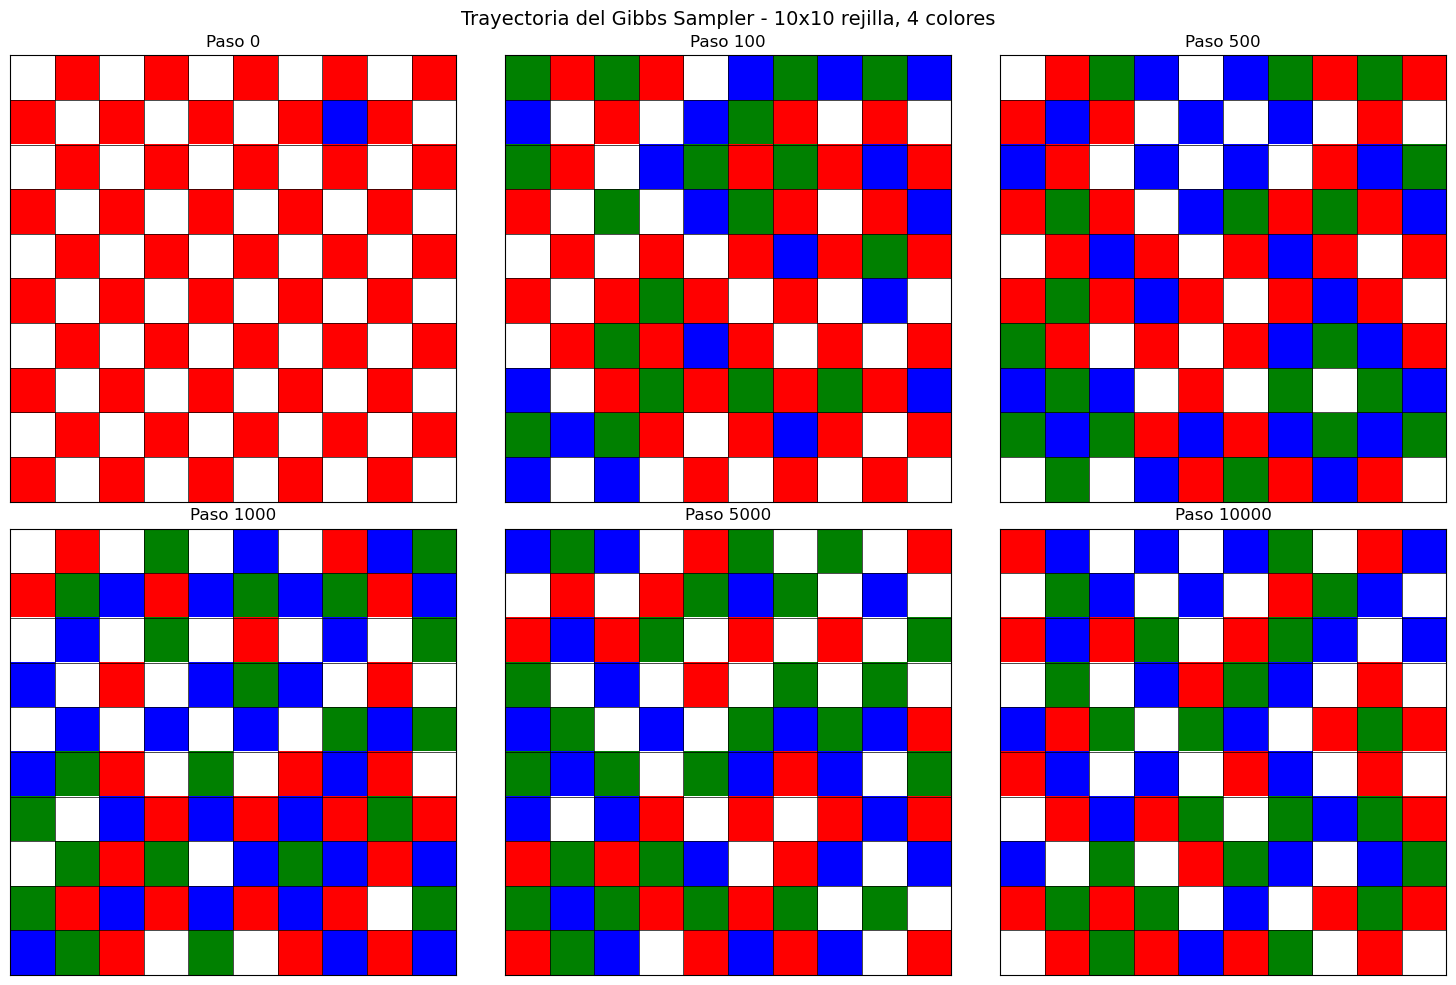

In [ ]:
# Ejemplo de visualización
K = 10
q = 4
num_steps = 10000
steps_to_show = [0, 100, 500, 1000, 5000]

plot_trajectory_q_coloration(K, q, num_steps, steps_to_show)

### Análisis del número de partículas de cada color

In [ ]:
def count_colors(grid, q):
    """
    Cuenta el número de celdas de cada color en la rejilla.
    """
    counts = Counter(grid.flatten())
    # Asegurar que todos los colores estén representados
    color_counts = [counts.get(c, 0) for c in range(q)]
    return color_counts

def analyze_color_distribution(K, q, num_samples=1000, num_steps=10000):
    """
    Analiza la distribución del número de partículas de cada color.
    """
    all_counts = []

    for _ in range(num_samples):
        grid, _ = gibbs_sampler_q_coloration(K, q, num_steps)
        counts = count_colors(grid, q)
        all_counts.append(counts)

    all_counts = np.array(all_counts)
    return all_counts

def plot_color_distribution(all_counts, K, q):
    """
    Visualiza la distribución del número de partículas de cada color.
    """
    fig, axes = plt.subplots(1, q, figsize=(4*q, 4))
    if q == 1:
        axes = [axes]

    color_names = ['Blanco', 'Rojo', 'Azul', 'Verde', 'Amarillo',
                   'Morado', 'Naranja', 'Rosa', 'Café', 'Gris']

    for color_idx in range(q):
        ax = axes[color_idx]
        color_counts = all_counts[:, color_idx]

        ax.hist(color_counts, bins=20, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Número de celdas')
        ax.set_ylabel('Frecuencia')

        if color_idx < len(color_names):
            title = f'Color {color_idx}: {color_names[color_idx]}'
        else:
            title = f'Color {color_idx}'
        ax.set_title(title)

        # Agregar estadísticas
        mean_count = np.mean(color_counts)
        std_count = np.std(color_counts)
        ax.axvline(mean_count, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_count:.1f}')
        ax.legend()

    fig.suptitle(f'Distribución de colores - Rejilla {K}x{K}, {q} colores', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Imprimir estadísticas
    print(f"\nEstadísticas para rejilla {K}x{K} con {q} colores:")
    print("-" * 50)
    for color_idx in range(q):
        color_counts = all_counts[:, color_idx]
        mean_count = np.mean(color_counts)
        std_count = np.std(color_counts)
        min_count = np.min(color_counts)
        max_count = np.max(color_counts)

        if color_idx < len(color_names):
            color_name = color_names[color_idx]
        else:
            color_name = f"Color {color_idx}"

        print(f"{color_name:15} - Media: {mean_count:6.2f}, Std: {std_count:5.2f}, Min: {min_count:3}, Max: {max_count:3}")

    print(f"\nNúmero total de celdas: {K*K}")
    print(f"Número esperado por color (uniforme): {K*K/q:.2f}")

Analizando distribución de colores para K=10, q=4...


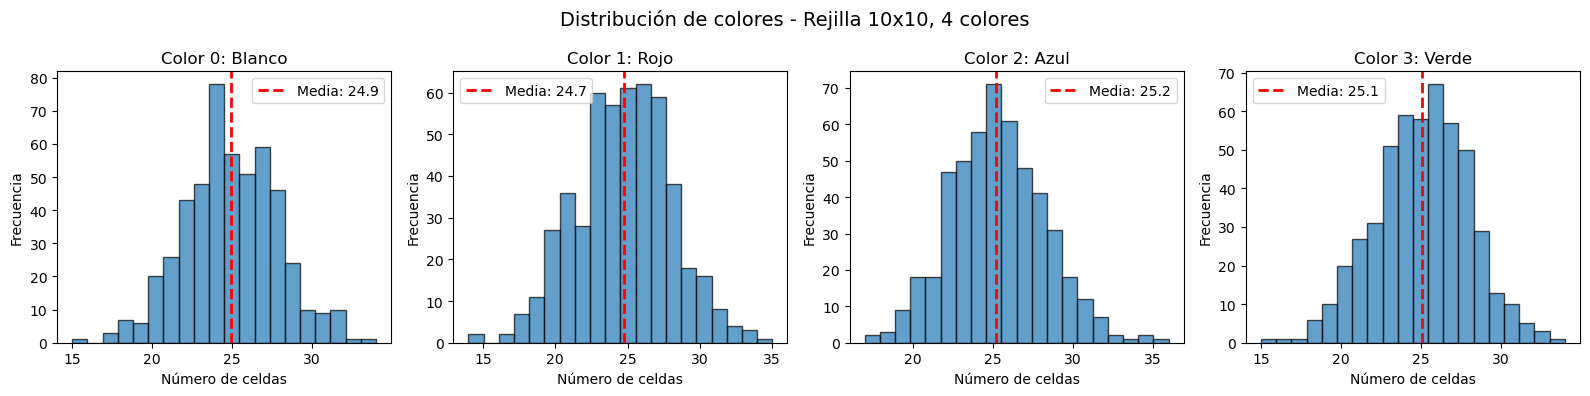


Estadísticas para rejilla 10x10 con 4 colores:
--------------------------------------------------
Blanco          - Media:  24.94, Std:  3.07, Min:  15, Max:  34
Rojo            - Media:  24.73, Std:  3.15, Min:  14, Max:  35
Azul            - Media:  25.24, Std:  3.12, Min:  17, Max:  36
Verde           - Media:  25.10, Std:  3.09, Min:  15, Max:  34

Número total de celdas: 100
Número esperado por color (uniforme): 25.00


In [ ]:
# Ejemplo de análisis
K = 10
q = 4
num_samples = 500
num_steps = 10000

print(f"Analizando distribución de colores para K={K}, q={q}...")
all_counts = analyze_color_distribution(K, q, num_samples, num_steps)
plot_color_distribution(all_counts, K, q)

### Comparación de diferentes tiempos de la cadena

In [ ]:
def analyze_convergence(K, q, chain_times, num_samples=100):
    """
    Analiza cómo cambia la distribución de colores con diferentes tiempos de cadena.
    """
    results = {}

    for t in chain_times:
        all_counts = []
        for _ in range(num_samples):
            grid, _ = gibbs_sampler_q_coloration(K, q, t)
            counts = count_colors(grid, q)
            all_counts.append(counts)
        results[t] = np.array(all_counts)

    return results

def plot_convergence_analysis(results, K, q, color_idx=0):
    """
    Visualiza cómo converge la distribución de un color específico.
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    times = sorted(results.keys())

    for idx, t in enumerate(times[:8]):
        ax = axes[idx]
        color_counts = results[t][:, color_idx]

        ax.hist(color_counts, bins=15, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Número de celdas')
        ax.set_ylabel('Frecuencia')
        ax.set_title(f't = {t:,} pasos')

        mean_count = np.mean(color_counts)
        ax.axvline(mean_count, color='red', linestyle='--', linewidth=2)
        ax.text(0.95, 0.95, f'μ={mean_count:.1f}',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fig.suptitle(f'Convergencia de la distribución - Color {color_idx}, Rejilla {K}x{K}, {q} colores', fontsize=14)
    plt.tight_layout()
    plt.show()

Analizando convergencia para K=8, q=3...


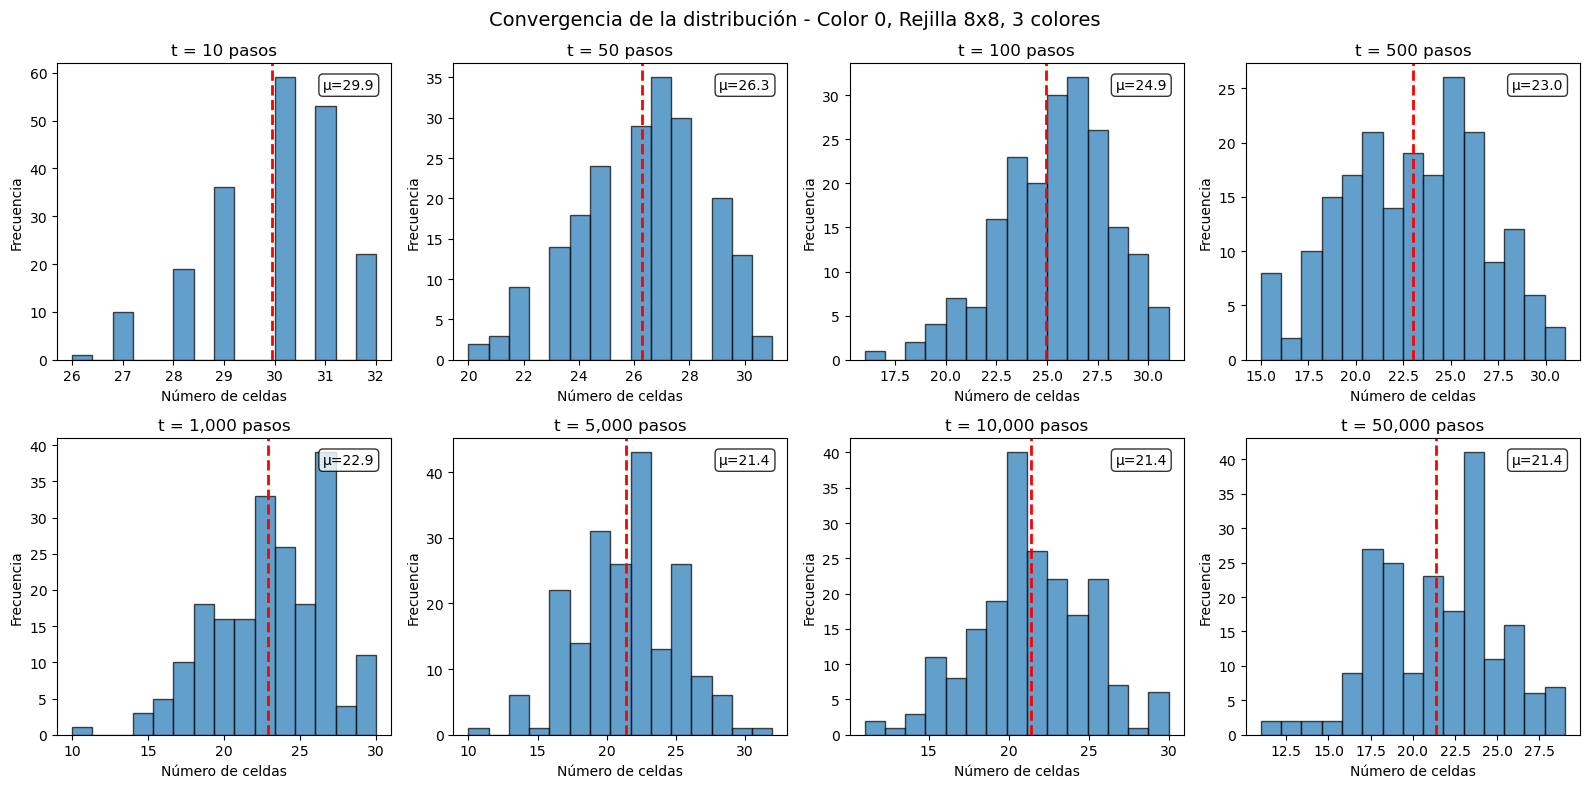

In [ ]:
# Análisis de convergencia
K = 8
q = 3
chain_times = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
num_samples = 200

print(f"Analizando convergencia para K={K}, q={q}...")
convergence_results = analyze_convergence(K, q, chain_times, num_samples)
plot_convergence_analysis(convergence_results, K, q, color_idx=0)

### Experimentos con diferentes valores de K y q

In [ ]:
def run_experiments(K_list, q_list, num_samples=100, num_steps=10000):
    """
    Ejecuta experimentos para diferentes combinaciones de K y q.
    """
    results = {}

    for K in K_list:
        results[K] = {}
        for q in q_list:
            print(f"Procesando K={K}, q={q}...")
            all_counts = analyze_color_distribution(K, q, num_samples, num_steps)

            # Calcular estadísticas
            mean_per_color = np.mean(all_counts, axis=0)
            std_per_color = np.std(all_counts, axis=0)

            results[K][q] = {
                'mean': mean_per_color,
                'std': std_per_color,
                'expected': K*K/q,
                'total': K*K
            }

    return results

def plot_summary_results(results):
    """
    Visualiza un resumen de los resultados experimentales.
    """
    K_list = sorted(results.keys())

    # Para cada K, graficar cómo varía la distribución con q
    fig, axes = plt.subplots(1, len(K_list), figsize=(5*len(K_list), 4))
    if len(K_list) == 1:
        axes = [axes]

    for idx, K in enumerate(K_list):
        ax = axes[idx]
        q_values = sorted(results[K].keys())

        means = []
        expected = []

        for q in q_values:
            # Promedio del número medio de celdas por color
            mean_value = np.mean(results[K][q]['mean'])
            means.append(mean_value)
            expected.append(results[K][q]['expected'])

        ax.plot(q_values, means, 'o-', label='Observado', markersize=8)
        ax.plot(q_values, expected, 's--', label='Esperado (K²/q)', markersize=6, alpha=0.7)

        ax.set_xlabel('Número de colores (q)')
        ax.set_ylabel('Celdas promedio por color')
        ax.set_title(f'Rejilla {K}x{K}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle('Distribución de colores vs número de colores disponibles', fontsize=14)
    plt.tight_layout()
    plt.show()

Ejecutando experimentos...
Procesando K=5, q=2...
Procesando K=5, q=3...
Procesando K=5, q=4...
Procesando K=5, q=6...
Procesando K=5, q=8...
Procesando K=10, q=2...
Procesando K=10, q=3...
Procesando K=10, q=4...
Procesando K=10, q=6...
Procesando K=10, q=8...
Procesando K=15, q=2...
Procesando K=15, q=3...
Procesando K=15, q=4...
Procesando K=15, q=6...
Procesando K=15, q=8...


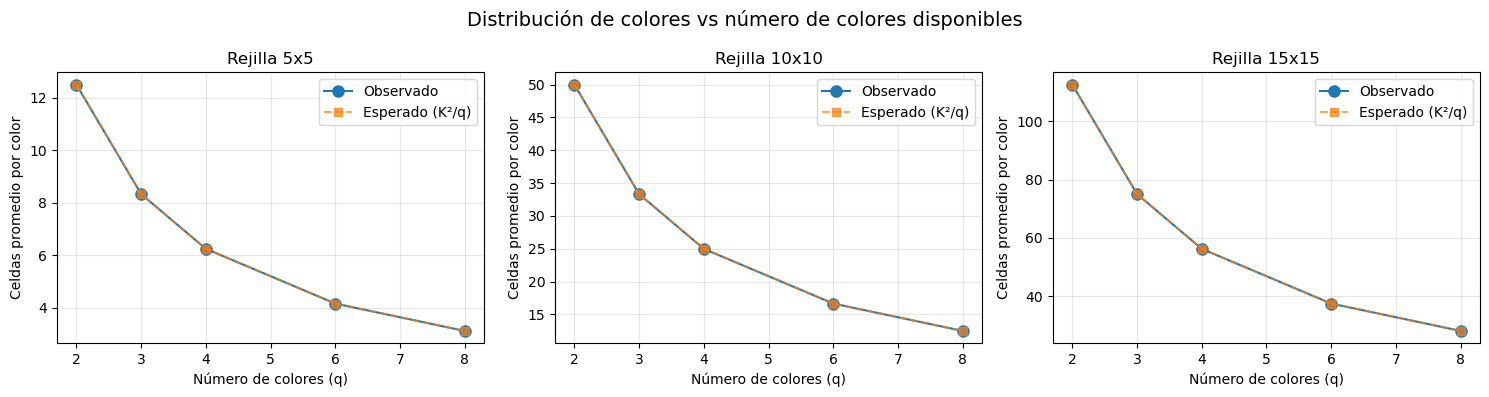

In [ ]:
# Ejecutar experimentos
K_list = [5, 10, 15]
q_list = [2, 3, 4, 6, 8]
num_samples = 100
num_steps = 10000

print("Ejecutando experimentos...")
experimental_results = run_experiments(K_list, q_list, num_samples, num_steps)
plot_summary_results(experimental_results)

### Visualización de múltiples muestras finales

In [ ]:
def generate_multiple_samples(K, q, num_samples=6, num_steps=50000):
    """
    Genera múltiples muestras independientes de q-coloraciones.
    """
    samples = []
    for _ in range(num_samples):
        grid, _ = gibbs_sampler_q_coloration(K, q, num_steps)
        samples.append(grid)
    return samples

def plot_multiple_samples(samples, K, q):
    """
    Visualiza múltiples muestras de q-coloraciones.
    """
    n_samples = len(samples)
    cols = min(3, n_samples)
    rows = (n_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if n_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else axes

    # Crear mapa de colores
    if q <= 10:
        colors = ['white', 'red', 'blue', 'green', 'yellow', 'purple',
                 'orange', 'pink', 'brown', 'gray']
        cmap = mcolors.ListedColormap(colors[:q])
    else:
        cmap = plt.cm.get_cmap('tab20', q)

    for idx, sample in enumerate(samples):
        if idx < len(axes):
            ax = axes[idx] if n_samples > 1 else axes
            im = ax.imshow(sample, cmap=cmap, vmin=0, vmax=q-1)

            # Agregar líneas de rejilla
            for i in range(K + 1):
                ax.axhline(i - 0.5, color='black', linewidth=0.5)
                ax.axvline(i - 0.5, color='black', linewidth=0.5)

            ax.set_xticks([])
            ax.set_yticks([])

            # Contar colores y mostrar en título
            counts = count_colors(sample, q)
            ax.set_title(f"Muestra {idx+1}\nColores: {counts}")

    # Ocultar ejes no utilizados
    if n_samples > 1:
        for idx in range(n_samples, len(axes)):
            axes[idx].axis('off')

    fig.suptitle(f"Muestras de q-coloraciones - Rejilla {K}x{K}, {q} colores", fontsize=14)
    plt.tight_layout()
    plt.show()

Generando 6 muestras independientes...


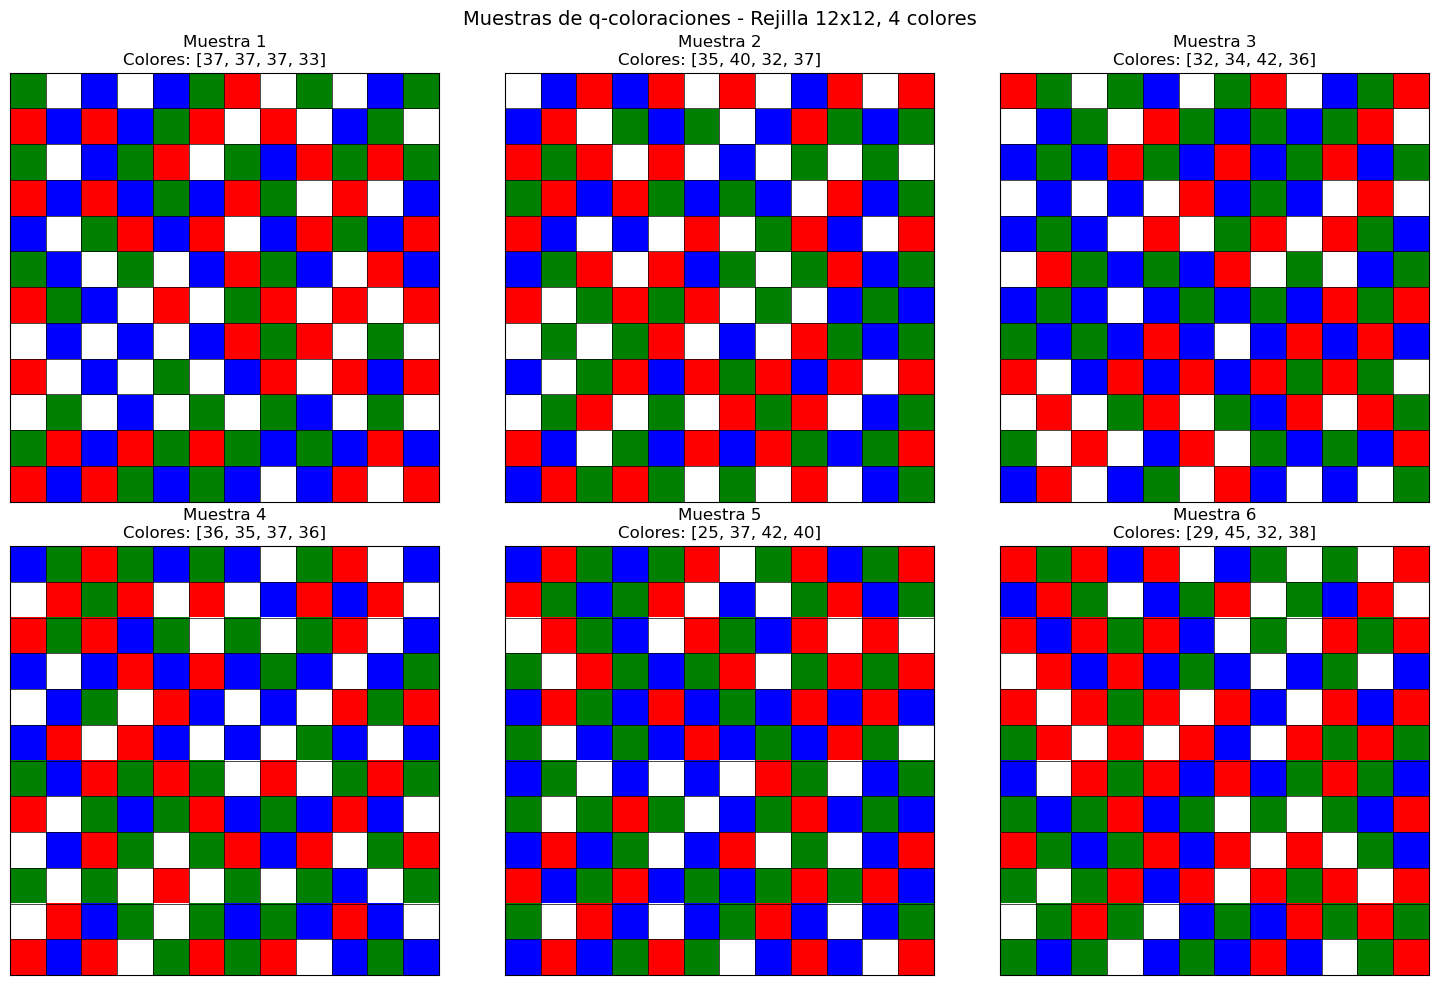

In [ ]:


# Generar y visualizar múltiples muestras
K = 12
q = 4
num_samples = 6
num_steps = 50000

print(f"Generando {num_samples} muestras independientes...")
samples = generate_multiple_samples(K, q, num_samples, num_steps)
plot_multiple_samples(samples, K, q)

### Análisis Final: Tabla resumen de resultados

In [ ]:
def create_summary_table(K_list, q_list, num_samples=500, num_steps=50000):
    data = []

    for K in K_list:
        for q in q_list:
            if q < 2:
                continue

            print(f"\nK={K}, q={q}:")
            all_counts = analyze_color_distribution(K, q, num_samples, num_steps)

            mean_per_color = np.mean(all_counts, axis=0)
            std_per_color = np.std(all_counts, axis=0)
            overall_mean = np.mean(mean_per_color)
            overall_std = np.mean(std_per_color)
            expected = K*K/q

            # Calcular χ² para cada muestra individual
            chi2_values = [np.sum((sample - expected)**2 / expected) for sample in all_counts]
            mean_chi2 = np.mean(chi2_values)
            std_chi2 = np.std(chi2_values)

            print(f"  χ² = {mean_chi2:.2f} ± {std_chi2:.2f}")

            data.append({
                'K': K,
                'q': q,
                'Total celdas': K*K,
                'Media observada': f"{overall_mean:.2f}",
                'Desv. estándar': f"{overall_std:.2f}",
                'Esperado (K²/q)': f"{expected:.2f}",
                'χ² medio': f"{mean_chi2:.2f}",
                'χ² desv.std': f"{std_chi2:.2f}",
                'gl (q-1)': q-1
            })

    df = pd.DataFrame(data)

    print("\n" + "="*80)
    print("TABLA RESUMEN")
    print("="*80)
    print(df.to_string(index=False))

    df.to_csv('q_coloraciones_resumen_CORRE.csv', index=False)
    print("\n✓ Guardado en: q_coloraciones_resumen_CORREGIDO.csv")

    return df



In [ ]:

# Crear tabla resumen
K_list = [5, 8, 10, 15, 20]
q_list = [2, 3, 4, 5, 8, 10]
num_samples = 200
num_steps = 50000

print("Creando tabla resumen...\n")
summary_df = create_summary_table(K_list, q_list, num_samples, num_steps)

Creando tabla resumen...


K=5, q=2:
  χ² = 0.04 ± 0.00

K=5, q=3:
  χ² = 1.50 ± 1.29

K=5, q=4:
  χ² = 1.48 ± 1.46

K=5, q=5:
  χ² = 1.82 ± 1.30

K=5, q=8:
  χ² = 4.76 ± 2.28

K=5, q=10:
  χ² = 6.47 ± 3.01

K=8, q=2:
  χ² = 0.00 ± 0.00

K=8, q=3:
  χ² = 1.74 ± 1.40

K=8, q=4:
  χ² = 1.71 ± 1.43

K=8, q=5:
  χ² = 2.03 ± 1.48

K=8, q=8:
  χ² = 4.40 ± 2.24

K=8, q=10:
  χ² = 6.87 ± 3.12

K=10, q=2:
  χ² = 0.00 ± 0.00

K=10, q=3:
  χ² = 2.11 ± 1.94

K=10, q=4:
  χ² = 1.47 ± 1.30

K=10, q=5:
  χ² = 1.98 ± 1.44

K=10, q=8:
  χ² = 4.65 ± 2.62

K=10, q=10:
  χ² = 6.53 ± 3.28

K=15, q=2:
  χ² = 0.00 ± 0.00

K=15, q=3:
  χ² = 2.65 ± 2.54

K=15, q=4:
  χ² = 1.73 ± 1.42

K=15, q=5:
  χ² = 2.12 ± 1.56

K=15, q=8:
  χ² = 4.60 ± 2.53

K=15, q=10:
  χ² = 6.58 ± 2.91

K=20, q=2:
  χ² = 0.00 ± 0.00

K=20, q=3:
  χ² = 3.50 ± 2.81

K=20, q=4:
  χ² = 1.58 ± 1.38

K=20, q=5:
  χ² = 1.97 ± 1.44

K=20, q=8:
  χ² = 4.47 ± 2.19

K=20, q=10:
  χ² = 5.92 ± 2.67

TABLA RESUMEN CORREGIDA
 K  q  Total celdas Media 

### Observaciones y Conclusiones

#### Resultados principales:

1. **Distribución uniforme**: Para una rejilla de tamaño $K \times K$ con $q$ colores, el número típico de celdas de cada color converge a aproximadamente $\frac{K^2}{q}$, lo cual coincide con una distribución uniforme.

2. **Convergencia**: La cadena de Markov converge rápidamente a la distribución estacionaria. Para rejillas pequeñas (K ≤ 10), 10,000 pasos son suficientes. Para rejillas más grandes, se recomienda usar al menos 50,000 pasos.

3. **Simetría**: Todos los colores tienen aproximadamente la misma probabilidad de aparecer en la distribución estacionaria, lo cual es esperado dado que el algoritmo de Gibbs sampler trata a todos los colores de manera simétrica.

4. **Restricción de coloración propia**: A diferencia del modelo Hard-Core donde la restricción es más fuerte (no puede haber partículas adyacentes), en las q-coloraciones solo se requiere que los vecinos tengan colores diferentes. Esto permite una mayor flexibilidad y resulta en una distribución más uniforme.

5. **Efecto del número de colores**: Cuando q = 2, solo es posible el patrón de tablero de ajedrez. A medida que q aumenta, hay más configuraciones posibles y la varianza en el número de celdas por color disminuye.

#### Comparación con el modelo Hard-Core:

- **Hard-Core**: El número típico de partículas es aproximadamente $\frac{K^2}{4}$ (hipótesis en el punto 1b).
- **q-coloraciones**: El número típico de celdas por color es $\frac{K^2}{q}$.

Esto muestra que las q-coloraciones tienen una distribución más predecible y uniforme que el modelo Hard-Core.